In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [3]:
print("PyTorch Version :", torch.__version__)
print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Device :", torch.cuda.get_device_name(0))

PyTorch Version : 2.7.1+cpu
CUDA Available : False


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device :", device)

Using Device : cpu


In [7]:
#Load data
#Load process datset
data = np.load(r"D:\Ai-Crop-Monitoring\models\data\processed\breizhcrops_processed.npz")

X = data["X"]
y = data["y"]


print("Features Shape :", X.shape)
print("Labels Shape   :", y.shape)

Features Shape : (122614, 585)
Labels Shape   : (122614,)


In [9]:
#Loading dataset
import breizhcrops as bzh
dataset = bzh.BreizhCrops("frh04")

In [10]:
#Extract features and labels from the dataset
from tqdm import tqdm

X = []
y = []
field_ids = []

for i in tqdm(range(len(dataset))):
    features, label, field_id = dataset[i]

    X.append(features.numpy())
    y.append(label.item())
    field_ids.append(field_id)

100%|██████████| 122614/122614 [15:46<00:00, 129.53it/s]


In [11]:
X = np.array(X)
y = np.array(y)
field_ids = np.array(field_ids)

print(X.shape)
print(y.shape)

(122614, 45, 13)
(122614,)


In [13]:
#Save the processed dataset as a compressed .npz file
import os
import numpy as np

os.makedirs("data/processed", exist_ok=True)

np.savez_compressed(
    "data/processed/breizhcrops_sequence.npz",
    X=X,
    y=y,
    field_ids=field_ids
)

print("✅ Processed dataset saved successfully!")

✅ Processed dataset saved successfully!


In [ ]:
# split data in train & test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(98091, 45, 13)
(24523, 45, 13)


In [ ]:
# Convert Numpy to tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [16]:
# Create custom dataset
class CropDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [17]:
# Create dataset objects
train_dataset = CropDataset(X_train, y_train)
test_dataset = CropDataset(X_test, y_test)

In [18]:
# Create Dataloaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [19]:
print("Training batches :", len(train_loader))
print("Testing batches  :", len(test_loader))

Training batches : 767
Testing batches  : 192


In [20]:
X_batch, y_batch = next(iter(train_loader))

print(X_batch.shape)
print(y_batch.shape)

torch.Size([128, 45, 13])
torch.Size([128])


In [36]:
#Build lstm model
class LSTMClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        # First LSTM Layer
        self.lstm = nn.LSTM(
            input_size=13,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        # Fully Connected Layers
        self.fc1 = nn.Linear(128, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 9)

    def forward(self, x):

        # LSTM Forward
        output, (hidden, cell) = self.lstm(x)

        # Last hidden state from last LSTM layer
        x = hidden[-1]

        # Classification Head
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [37]:
# create model
model = LSTMClassifier().to(device)
print(model)

LSTMClassifier(
  (lstm): LSTM(13, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=9, bias=True)
)


In [38]:
# loss function
criterion = nn.CrossEntropyLoss()

In [39]:
# optmizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

In [40]:
#learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [41]:
# training loop 
num_epochs = 40

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward
        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        # Backward
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    scheduler.step(epoch_loss)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/40] Loss: 1.6102
Epoch [2/40] Loss: 1.2304
Epoch [3/40] Loss: 0.8061
Epoch [4/40] Loss: 0.7192
Epoch [5/40] Loss: 0.6742
Epoch [6/40] Loss: 0.6331
Epoch [7/40] Loss: 0.5952
Epoch [8/40] Loss: 0.5678
Epoch [9/40] Loss: 0.5529
Epoch [10/40] Loss: 0.5477
Epoch [11/40] Loss: 0.5382
Epoch [12/40] Loss: 0.5299
Epoch [13/40] Loss: 0.5224
Epoch [14/40] Loss: 0.5225
Epoch [15/40] Loss: 0.5157
Epoch [16/40] Loss: 0.5096
Epoch [17/40] Loss: 0.5063
Epoch [18/40] Loss: 0.5021
Epoch [19/40] Loss: 0.4974
Epoch [20/40] Loss: 0.4953
Epoch [21/40] Loss: 0.4921
Epoch [22/40] Loss: 0.4892
Epoch [23/40] Loss: 0.4846
Epoch [24/40] Loss: 0.4802
Epoch [25/40] Loss: 0.4806
Epoch [26/40] Loss: 0.4777
Epoch [27/40] Loss: 0.4739
Epoch [28/40] Loss: 0.4725
Epoch [29/40] Loss: 0.4692
Epoch [30/40] Loss: 0.4684
Epoch [31/40] Loss: 0.4644
Epoch [32/40] Loss: 0.4615
Epoch [33/40] Loss: 0.4601
Epoch [34/40] Loss: 0.4578
Epoch [35/40] Loss: 0.4558
Epoch [36/40] Loss: 0.4516
Epoch [37/40] Loss: 0.4519
Epoch [38/

In [42]:
model.eval()

LSTMClassifier(
  (lstm): LSTM(13, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=9, bias=True)
)

In [43]:
y_true = []
y_pred = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, dim=1)

        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [44]:
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [45]:
accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 0.7961
Accuracy : 79.61%


In [46]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      1196
           1       0.95      0.95      0.95      3399
           2       0.97      0.96      0.96       647
           3       0.96      0.97      0.96      6267
           5       0.00      0.00      0.00       111
           6       0.00      0.00      0.00         2
           7       0.58      0.62      0.60      5223
           8       0.71      0.69      0.70      7678

    accuracy                           0.80     24523
   macro avg       0.63      0.64      0.63     24523
weighted avg       0.79      0.80      0.79     24523



C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [47]:
import seaborn as sns

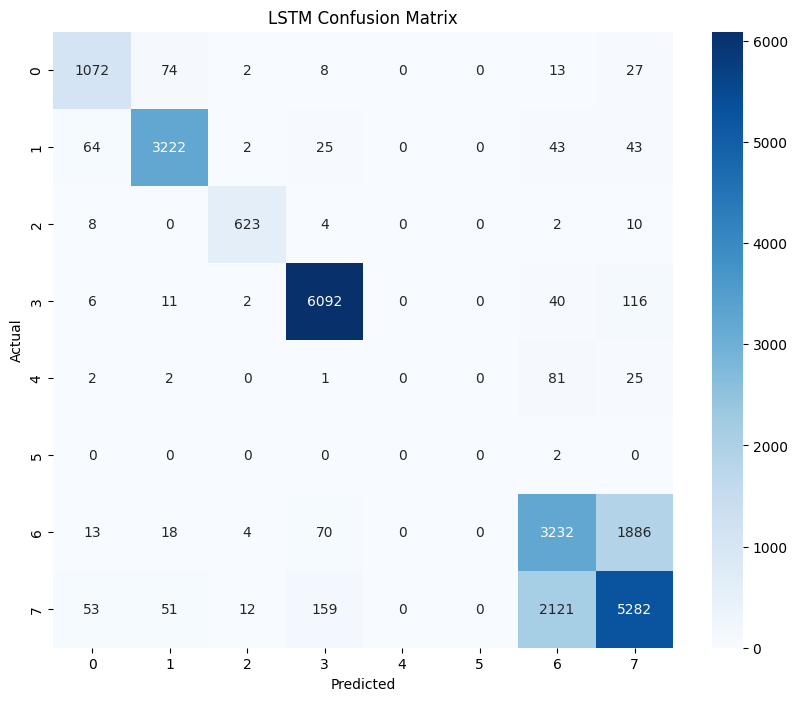

In [48]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")

plt.show()

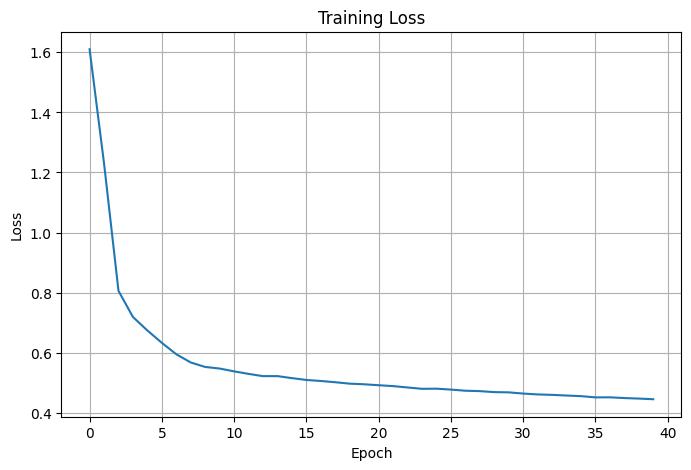

In [49]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

In [50]:
import os

os.makedirs("../models", exist_ok=True)

torch.save(
    model.state_dict(),
    "../models/lstm_crop_classifier.pth"
)

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [51]:
model = LSTMClassifier().to(device)
model.load_state_dict(torch.load("../models/lstm_crop_classifier.pth"))
model.eval()

LSTMClassifier(
  (lstm): LSTM(13, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=9, bias=True)
)